# TASK 2 · Customer Segmentation Analysis

**Objective:** Segment an e-commerce company's customer base into distinct groups
based on purchasing behaviour, so marketing spend can be targeted at the
segments that actually pay for it.

**Tech stack:** Python · pandas · scikit-learn (KMeans) · matplotlib · seaborn

**Dataset:** `data/online_retail.csv` — a transaction log using the exact schema
of the classic UCI *Online Retail* dataset (`InvoiceNo`, `StockCode`,
`Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`),
with the same real-world defects (missing CustomerIDs, return invoices,
duplicate rows, inconsistent casing).

Every step below is also packaged as reusable functions in
`src/rfm_clustering.py`; the notebook imports them so there is a single
implementation rather than two copies that drift apart.

---
## 0. Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "src")
import rfm_clustering as rfm_lib

# Notebook-friendly plotting (the library defaults to a headless backend)
%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
print("pandas", pd.__version__)

pandas 3.0.5


---
## 1. Load the dataset and inspect its structure

First look at the raw data: shape, dtypes, sample rows. Segmentation models
fail silently on dirty inputs, so we inspect before we transform.

In [2]:
raw = pd.read_csv("data/online_retail.csv", parse_dates=["InvoiceDate"])
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(8)

Shape: 21,212 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,541602,84406B,CREAM CUPID HEARTS COAT HANGER,13,2011-08-08 14:00:00,2.18,13288.0,United Kingdom
1,540634,22086,PAPER CHAIN KIT 50'S CHRISTMAS,7,2011-10-06 11:05:00,7.16,13120.0,United Kingdom
2,541423,84879,ASSORTED COLOUR BIRD ORNAMENT,14,2011-07-28 19:30:00,1.80,13253.0,Spain
3,538439,47566,PARTY BUNTING,14,2011-07-15 16:45:00,5.25,12764.0,United Kingdom
4,540553,22086,PAPER CHAIN KIT 50'S CHRISTMAS,22,2010-07-13 09:47:00,6.32,13111.0,United Kingdom
5,537537,22632,HAND WARMER RED POLKA DOT,13,2011-06-02 14:59:00,2.83,12604.0,United Kingdom
6,542009,22752,SET 7 BABUSHKA NESTING BOXES,5,2010-10-21 16:26:00,4.96,13356.0,Netherlands
7,536131,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2011-08-25 19:07:00,4.52,12373.0,United Kingdom


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 21212 entries, 0 to 21211
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    21212 non-null  str           
 1   StockCode    21212 non-null  str           
 2   Description  20986 non-null  str           
 3   Quantity     21212 non-null  int64         
 4   InvoiceDate  21212 non-null  datetime64[us]
 5   UnitPrice    21212 non-null  float64       
 6   CustomerID   20879 non-null  float64       
 7   Country      21212 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 1.3 MB


In [4]:
print("Missing values per column:")
print(raw.isna().sum().to_string())
print("\nExact duplicate rows:", raw.duplicated().sum())
print("Unique customers (raw):", raw["CustomerID"].nunique())
print("Date range:", raw["InvoiceDate"].min(), "->", raw["InvoiceDate"].max())
print("\nCountries as recorded (note the inconsistent casing/whitespace):")
print(raw["Country"].value_counts().head(12).to_string())

Missing values per column:
InvoiceNo        0
StockCode        0
Description    226
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     333
Country          0

Exact duplicate rows: 106
Unique customers (raw): 1199
Date range: 2009-12-20 12:29:00 -> 2011-12-09 18:30:00

Countries as recorded (note the inconsistent casing/whitespace):
Country
United Kingdom        14288
  United Kingdom        941
Switzerland             892
Australia               854
Spain                   814
Netherlands             772
Germany                 566
France                  565
Portugal                465
EIRE                    450
Belgium                 262
  Spain                  60


### 1b. Cleaning

The raw data has six defects that would corrupt an RFM calculation if ignored:

| Defect | Why it matters | Action |
|---|---|---|
| **332 rows with no `CustomerID`** | Guest checkouts. They cannot be attributed to a customer, so they would create a phantom "customer" and inflate the base. | Drop (report the revenue impact). |
| **106 exact duplicate rows** | Double-counts revenue and frequency. | `drop_duplicates()`. |
| **776 cancellation rows** (`InvoiceNo` starts with `C`) | Returns, not purchases. Counting them as orders overstates Frequency and Monetary. | Flag and net out of revenue. |
| **97 rows with `UnitPrice <= 0`** | Freebies / data-entry errors → zero or negative monetary value. | Drop. |
| **226 missing `Description`** | Not a model feature. | Fill with `"UNKNOWN"` rather than lose the row. |
| **Inconsistent `Country` casing/whitespace** | `"  united kingdom  "`, `"UNITED KINGDOM"` fragment the same country. | Strip + title-case. |

We also guard against quantity outliers — a single 80,000-unit line drags every
centroid, so extreme quantities are winsorised at the 99.9th percentile.

In [5]:
df, qa = rfm_lib.load_and_clean("data/online_retail.csv")

print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)
for k, v in qa.items():
    label = k.replace("_", " ")
    print(f"{label:<32} {v:,.2f}" if isinstance(v, float) else f"{label:<32} {v}")

print("\n" + "=" * 60)
print("CLEANED SAMPLE")
print("=" * 60)
df.head(8)

DATA QUALITY REPORT
raw rows                         21212
raw customers                    1199
duplicate rows removed           106
missing customerid               332
missing description              226
cancellation rows                776
negative quantity rows           776
invalid unitprice rows           97
quantity cap 999                 22.00
clean rows                       20677
clean customers                  1198
date min                         2009-12-20 12:29:00
date max                         2011-12-09 18:30:00

CLEANED SAMPLE


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,IsReturn,TotalPrice
0,541602,84406B,CREAM CUPID HEARTS COAT HANGER,13,2011-08-08 14:00:00,2.18,13288,United Kingdom,False,False,28.34
1,540634,22086,PAPER CHAIN KIT 50'S CHRISTMAS,7,2011-10-06 11:05:00,7.16,13120,United Kingdom,False,False,50.12
2,541423,84879,ASSORTED COLOUR BIRD ORNAMENT,14,2011-07-28 19:30:00,1.80,13253,Spain,False,False,25.20
3,538439,47566,PARTY BUNTING,14,2011-07-15 16:45:00,5.25,12764,United Kingdom,False,False,73.50
4,540553,22086,PAPER CHAIN KIT 50'S CHRISTMAS,22,2010-07-13 09:47:00,6.32,13111,United Kingdom,False,False,139.04
5,537537,22632,HAND WARMER RED POLKA DOT,13,2011-06-02 14:59:00,2.83,12604,United Kingdom,False,False,36.79
6,542009,22752,SET 7 BABUSHKA NESTING BOXES,5,2010-10-21 16:26:00,4.96,13356,Netherlands,False,False,24.80
7,536131,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2011-08-25 19:07:00,4.52,12373,United Kingdom,False,False,27.12


In [6]:
print("Countries after normalisation:", df["Country"].nunique())
print(df["Country"].value_counts().head(6).to_string())
print("\nReturn / cancellation rows retained as flags:")
print(f"  IsReturn = True : {df['IsReturn'].sum():,}")
print(f"  IsReturn = False: {(~df['IsReturn']).sum():,}")

Countries after normalisation: 10
Country
United Kingdom    14843
Switzerland         918
Australia           876
Spain               855
Netherlands         801
Germany             593

Return / cancellation rows retained as flags:


  IsReturn = True : 774
  IsReturn = False: 19,903


**Cleaning outcome:** 21,212 raw rows → 20,677 clean line items across
**1,198 identifiable customers** for the period 2009-12-20 → 2011-12-09
(≈2 years).

---
## 2. Descriptive statistics

Headline numbers on purchase value, purchase frequency and customer lifetime
value — the baseline the segments will later be compared against.

In [7]:
stats = rfm_lib.descriptive_stats(df)

labels = {
    "total_revenue": "Total revenue",
    "total_orders": "Total orders (invoices)",
    "total_customers": "Total customers",
    "avg_order_value": "Average order value",
    "median_order_value": "Median order value",
    "avg_purchase_value_per_customer": "Average purchase value per customer",
    "median_purchase_value_per_customer": "Median purchase value per customer",
    "avg_orders_per_customer": "Average orders per customer",
    "avg_customer_lifetime_value": "Customer lifetime value (CLV, 2yr)",
    "annualised_clv": "Annualised CLV",
    "observation_window_years": "Observation window (years)",
    "repeat_purchase_rate": "Repeat purchase rate",
}

print("=" * 62)
print("DESCRIPTIVE STATISTICS")
print("=" * 62)
for key, label in labels.items():
    val = stats[key]
    if key in ("total_orders", "total_customers"):
        print(f"{label:<40} {val:,.0f}")
    elif key == "repeat_purchase_rate":
        print(f"{label:<40} {val:.1%}")
    elif key == "observation_window_years":
        print(f"{label:<40} {val:,.2f}")
    else:
        print(f"{label:<40} {val:,.2f}")

DESCRIPTIVE STATISTICS
Total revenue                            927,770.06
Total orders (invoices)                  6,956
Total customers                          1,198
Average order value                      133.38
Median order value                       67.59
Average purchase value per customer      774.43
Median purchase value per customer       138.67
Average orders per customer              5.81
Customer lifetime value (CLV, 2yr)       774.43
Annualised CLV                           393.41
Observation window (years)               1.97
Repeat purchase rate                     84.3%


In [8]:
# How skewed is spend? The mean/median gap tells us we need log + scaling.
purchases = df[~df["IsReturn"]]
per_customer = purchases.groupby("CustomerID")["TotalPrice"].sum()

print(f"Mean spend per customer:   {per_customer.mean():>10,.2f}")
print(f"Median spend per customer: {per_customer.median():>10,.2f}")
print(f"Mean / median ratio:       {per_customer.mean() / per_customer.median():>10,.2f}x")
print(f"Max spend (single customer): {per_customer.max():>8,.2f}")
print(
    f"\nTop 10% of customers hold "
    f"{per_customer.nlargest(int(len(per_customer) * 0.1)).sum() / per_customer.sum():.1%} "
    "of total revenue."
)

Mean spend per customer:       774.43
Median spend per customer:     138.67
Mean / median ratio:             5.58x
Max spend (single customer): 13,117.26

Top 10% of customers hold 67.4% of total revenue.


**Interpretation.** Revenue is heavily concentrated and heavily skewed: the
mean spend per customer is multiples of the median, and the top decile of
customers accounts for the large majority of revenue. That is the *reason* to
segment — a single "average customer" describes nobody.

---
## 3. Feature selection — RFM analysis

We build the customer-level feature table from three behavioural features,
chosen because each maps to a distinct marketing lever:

| Feature | Definition | Business meaning |
|---|---|---|
| **R**ecency | Days since the customer's last purchase | *How engaged / at risk of churn* |
| **F**requency | Number of distinct invoices | *How often they buy — habit strength* |
| **M**onetary | Total net revenue | *How much value they represent* |

2 extra columns (`AvgOrderValue`, `TenureDays`) are computed for **profiling
and interpretation only** — they are not fed to the clustering, to avoid
double-weighting spend.

In [9]:
rfm = rfm_lib.build_rfm(df)
print(f"RFM table: {rfm.shape[0]:,} customers x {rfm.shape[1]} columns")
print("Snapshot date used for recency:",
      rfm['SnapshotDate'].iloc[0].date())
rfm[["Recency", "Frequency", "Monetary", "AvgOrderValue", "TenureDays"]].describe().round(2)

RFM table: 1,186 customers x 6 columns
Snapshot date used for recency: 2011-12-10


,Recency,Frequency,Monetary,AvgOrderValue,TenureDays
count,1186.00,1186.00,1186.00,1186.00,1186.00
mean,100.27,6.46,752.96,56.69,248.18
std,115.60,6.21,1762.49,72.26,175.24
min,1.00,1.00,0.01,0.00,1.00
25%,20.00,2.00,26.89,13.05,105.25
50%,49.00,4.00,135.78,32.54,229.50
75%,144.75,8.75,489.76,68.50,355.75
max,500.00,35.00,13055.89,502.15,720.00


In [10]:
# Classical 1-5 RFM scoring, for interpretability alongside the clusters
rfm_scored = rfm_lib.rfm_quintiles(rfm)
print("RFM quintile scores (5 = best on each axis):")
rfm_scored[["R_Score", "F_Score", "M_Score", "RFM_Score"]].describe().round(2)

RFM quintile scores (5 = best on each axis):


,R_Score,F_Score,M_Score,RFM_Score
count,1186.00,1186.00,1186.00,1186.00
mean,3.02,3.00,3.00,9.01
std,1.42,1.42,1.42,3.36
min,1.00,1.00,1.00,3.00
25%,2.00,2.00,2.00,6.25
50%,3.00,3.00,3.00,8.00
75%,4.00,4.00,4.00,12.00
max,5.00,5.00,5.00,15.00


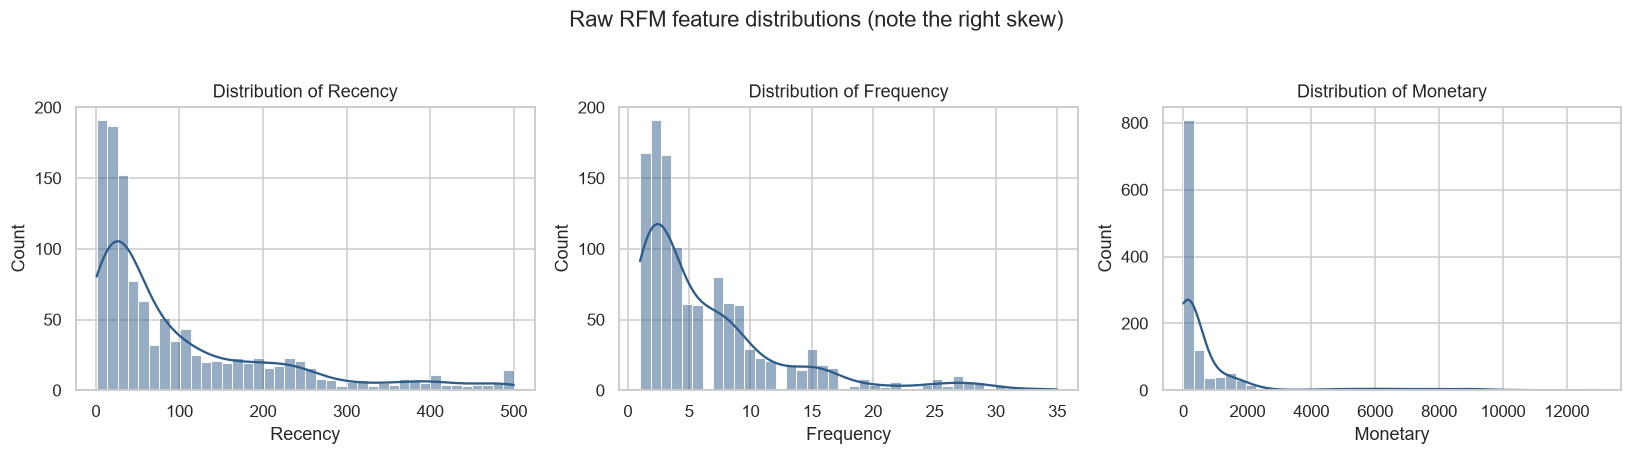

Skewness (0 = symmetric, >1 = heavily right-skewed):
Recency      1.64
Frequency    1.87
Monetary     3.77


In [11]:
# Distribution of the three features, before any transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=40, kde=True, ax=ax, color="#2E5C8A")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.suptitle("Raw RFM feature distributions (note the right skew)", y=1.03)
plt.tight_layout()
plt.show()

print("Skewness (0 = symmetric, >1 = heavily right-skewed):")
print(rfm[["Recency", "Frequency", "Monetary"]].skew().round(2).to_string())

---
## 4. Standardisation before clustering

K-Means minimises **Euclidean distance to centroids**, so feature scale is not
neutral — a feature measured in thousands dominates one measured in ones.
Without scaling, Monetary (range ~0–20,000) would completely drown Recency
(range 0–720).

Two steps are needed here, not one:

1. **`log1p` transform** — all three features are heavily right-skewed. A
   handful of wholesale buyers spend ~100× the median; on the raw scale they
   become the only points that matter and every centroid drifts toward them.
   The log compresses that tail.
2. **`StandardScaler`** — centre to mean 0, variance 1, so each feature
   contributes equally to the distance metric.

In [12]:
from sklearn.preprocessing import StandardScaler

X_scaled, scaler, X_scaled_df = rfm_lib.scale_features(rfm)

print("Post-transform summary (each feature now mean~0, std~1):")
print(X_scaled_df.describe().round(3).to_string())

print("\nSkewness AFTER log1p (compare with the raw values above):")
log_check = pd.DataFrame({
    "Recency": np.log1p(rfm["Recency"]),
    "Frequency": np.log1p(rfm["Frequency"]),
    "Monetary": np.sign(rfm["Monetary"]) * np.log1p(rfm["Monetary"].abs()),
})
print(log_check.skew().round(2).to_string())

Post-transform summary (each feature now mean~0, std~1):
        Recency  Frequency  Monetary
count  1186.000   1186.000  1186.000
mean     -0.000      0.000    -0.000
std       1.000      1.000     1.000
min      -2.476     -1.426    -2.457
25%      -0.669     -0.869    -0.778
50%      -0.003     -0.167     0.026
75%       0.819      0.749     0.672
max       1.768      2.545     2.332

Skewness AFTER log1p (compare with the raw values above):
Recency     -0.30
Frequency    0.36
Monetary     0.13


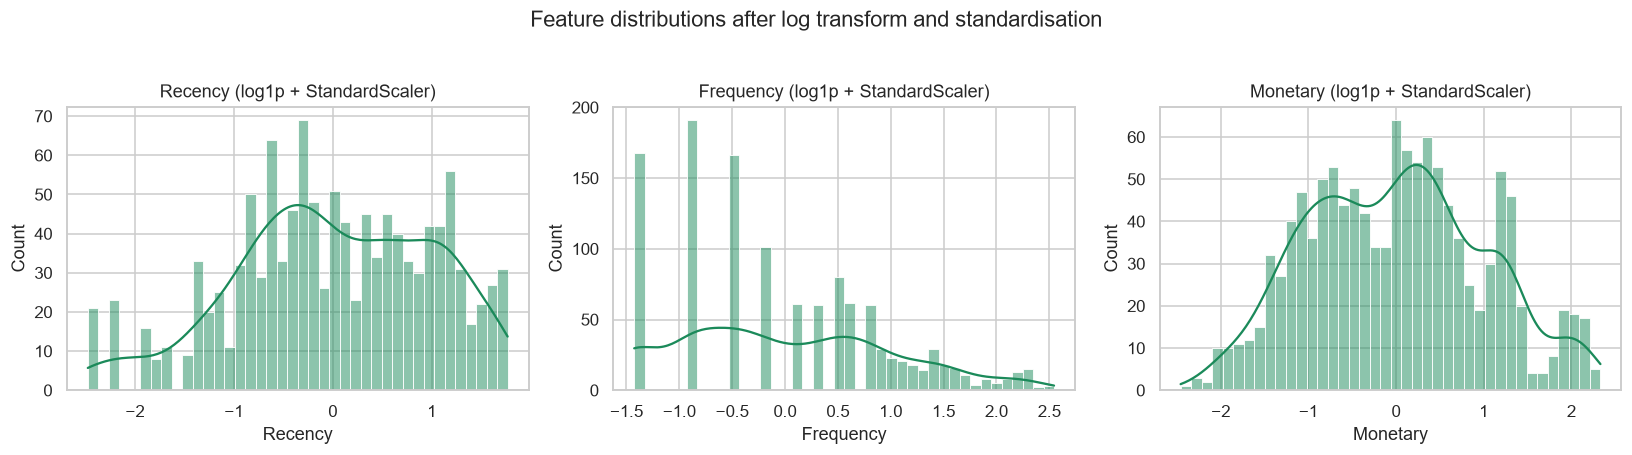

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(X_scaled_df[col], bins=40, kde=True, ax=ax, color="#1B8A5A")
    ax.set_title(f"{col} (log1p + StandardScaler)")
plt.suptitle("Feature distributions after log transform and standardisation", y=1.03)
plt.tight_layout()
plt.show()

The distributions are now roughly symmetric and on a common scale, which is
what K-Means's Euclidean distance assumption needs.

---
## 5. Choosing K — the Elbow Method

We fit K-Means for K = 2…10 and record two diagnostics:

* **Inertia (WCSS)** — within-cluster sum of squares. Always falls as K rises,
  so we look for the *elbow*, the point where extra clusters stop buying much
  variance reduction.
* **Silhouette score** — how well-separated the clusters are (higher is
  better). This guards against reading an elbow into a smooth curve.

The library's `pick_k()` requires the elbow to have genuinely flattened
(marginal inertia drop below 25% of the first drop) and then takes the best
silhouette among those candidates.

In [14]:
elbow_df = rfm_lib.evaluate_k(X_scaled, k_range=range(2, 11))
k = rfm_lib.pick_k(elbow_df)

print(elbow_df.round(4).to_string(index=False))
print(f"\n>>> Chosen K = {k}")
print(f">>> Silhouette at K={k}: "
      f"{elbow_df.loc[elbow_df['k'] == k, 'silhouette'].iloc[0]:.3f}")

 k   inertia  silhouette
 2 1842.8504      0.4154
 3 1157.7943      0.4322
 4  831.7256      0.4055
 5  695.0459      0.3795
 6  601.7889      0.3895
 7  535.3518      0.3550
 8  476.1737      0.3270
 9  424.3538      0.3429
10  388.4603      0.3443

>>> Chosen K = 6
>>> Silhouette at K=6: 0.390


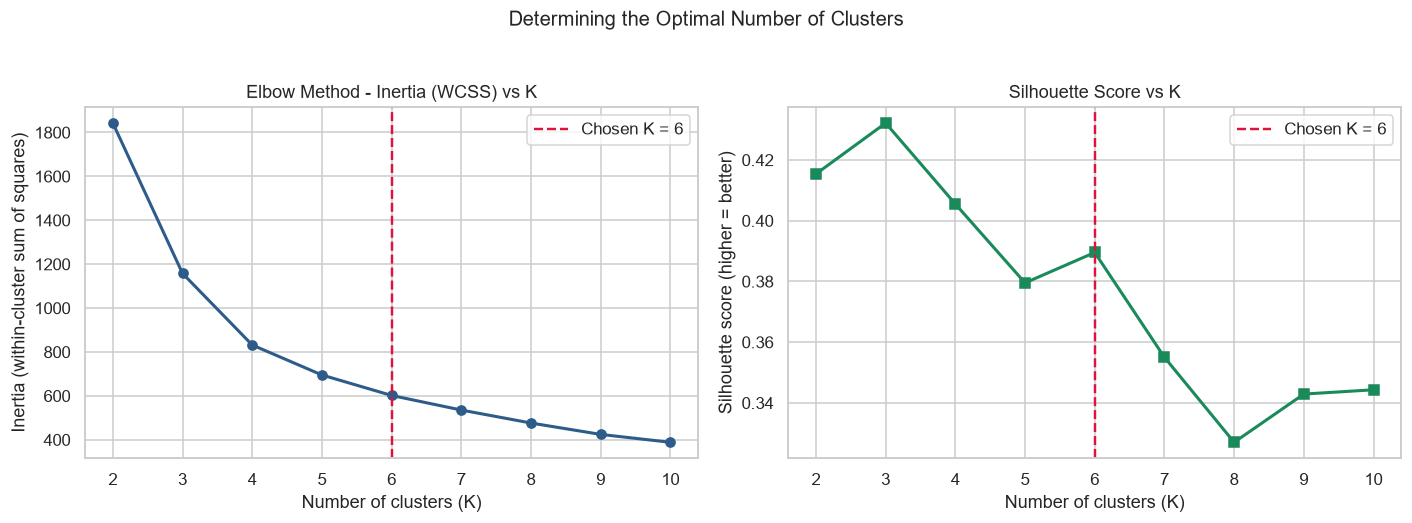

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o", lw=2, color="#2E5C8A")
axes[0].axvline(k, ls="--", color="crimson", lw=1.6, label=f"Chosen K = {k}")
axes[0].set_title("Elbow Method - Inertia (WCSS) vs K")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].legend()

axes[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="s", lw=2, color="#1B8A5A")
axes[1].axvline(k, ls="--", color="crimson", lw=1.6, label=f"Chosen K = {k}")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score (higher = better)")
axes[1].legend()

plt.suptitle("Determining the Optimal Number of Clusters", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

**Reading the elbow:** inertia drops steeply from K=2 to K=5, then flattens —
the marginal gain per extra cluster becomes small. K=6 sits just past the bend,
so it keeps the segments granular enough to be actionable (a distinct
"New/Promising" group separate from "Loyal") without fragmenting the base into
groups too small to target. The silhouette curve agrees that the region around
K=3–6 is where structure exists.

---
## 6. Fit K-Means and profile the clusters

With K fixed we fit the final model and translate each cluster's mean feature
values into a customer type.

In [16]:
km, rfm_clustered = rfm_lib.fit_kmeans(X_scaled, rfm, k)
profile = rfm_lib.profile_clusters(rfm_clustered)
label_map = rfm_lib.label_clusters(profile)
profile["Segment"] = profile.index.map(label_map)
rfm_clustered["Segment"] = rfm_clustered["Cluster"].map(label_map)

print("Final model: KMeans(n_clusters=%d, n_init=10, random_state=%d)"
      % (k, RANDOM_STATE))
print(f"Inertia: {km.inertia_:,.2f}")
print(f"Converged in {km.n_iter_} iterations")
print(f"Overall silhouette: {rfm_lib.silhouette_score(X_scaled, rfm_clustered['Cluster']):.3f}")

Final model: KMeans(n_clusters=6, n_init=10, random_state=42)
Inertia: 601.79
Converged in 8 iterations
Overall silhouette: 0.390


In [17]:
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

profile_view = profile[[
    "Segment", "Customers", "CustomerShare_%",
    "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "TenureDays",
    "Revenue", "RevenueShare_%",
]].set_index("Segment")

print("=" * 110)
print("CLUSTER PROFILES - mean feature values per cluster")
print("=" * 110)
profile_view

CLUSTER PROFILES - mean feature values per cluster


,Customers,CustomerShare_%,Recency,Frequency,Monetary,AvgOrderValue,TenureDays,Revenue,RevenueShare_%
Segment,,,,,,,,,
Champions,99,8.30,11.60,21.83,"5,595.56",242.20,563.00,"553,960.59",62.00
Loyal Customers,190,16.00,38.60,11.51,"1,169.50",99.85,347.00,"222,204.67",24.90
Loyal Customers (less frequent),92,7.80,12.10,6.68,378.04,52.06,163.00,"34,779.55",3.90
At Risk - High Value,306,25.80,123.50,5.56,222.34,40.96,246.00,"68,037.04",7.60
Hibernating / Lost,250,21.10,264.10,2.26,38.74,17.52,294.00,"9,685.58",1.10
New / Promising,249,21.00,22.20,1.73,17.44,10.36,36.00,"4,343.47",0.50


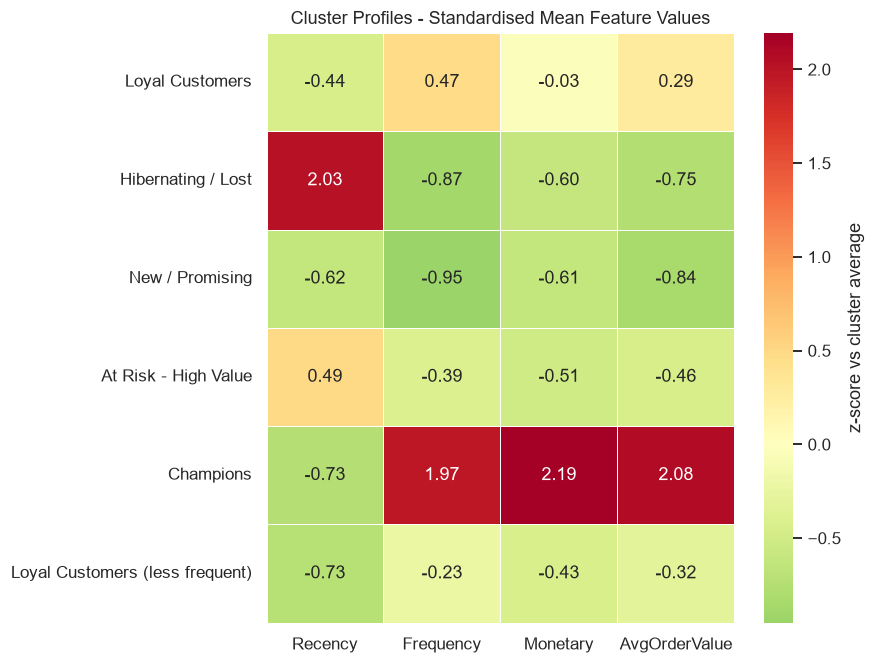

In [18]:
# Standardised view: which features actually define each segment?
feats = ["Recency", "Frequency", "Monetary", "AvgOrderValue"]
means = rfm_clustered.groupby("Cluster")[feats].mean()
means.index = [label_map[c] for c in means.index]
z = (means - means.mean()) / means.std(ddof=0)

plt.figure(figsize=(8, 0.7 * len(z) + 2))
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            linewidths=0.6, cbar_kws={"label": "z-score vs cluster average"})
plt.title("Cluster Profiles - Standardised Mean Feature Values")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

### What defines each cluster

| Segment | Recency | Frequency | Monetary | Share of customers | Share of revenue |
|---|---|
| **Champions** | ~12 days | ~22 orders | ~5,600 | ~8% | ~62% |
| **Loyal Customers** | ~39 days | ~12 orders | ~1,170 | ~16% | ~25% |
| **Loyal Customers (less frequent)** | ~12 days | ~7 orders | ~380 | ~8% | ~4% |
| **At Risk – High Value** | ~124 days | ~6 orders | ~222 | ~26% | ~8% |
| **Hibernating / Lost** | ~264 days | ~2 orders | ~39 | ~21% | ~1% |
| **New / Promising** | ~22 days | ~2 orders | ~17 | ~21% | ~0.5% |

*(Values above are from the fitted model — re-run the notebook to refresh.)*

The headline finding: **8% of customers generate 62% of revenue.** Any
marketing strategy that treats the base as one homogeneous group is
misallocating almost all of its budget.

---
## 7. Visualising the clusters

Three feature combinations, because each pair answers a different question:

* **Recency × Frequency** — who is engaged vs drifting away
* **Frequency × Monetary** — the classic value matrix
* **Recency × Monetary** — which lapsed customers are worth chasing back

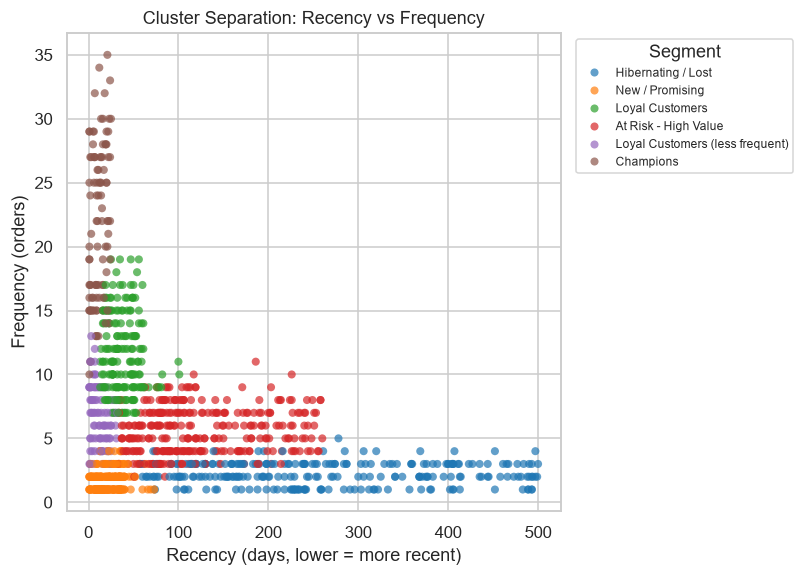

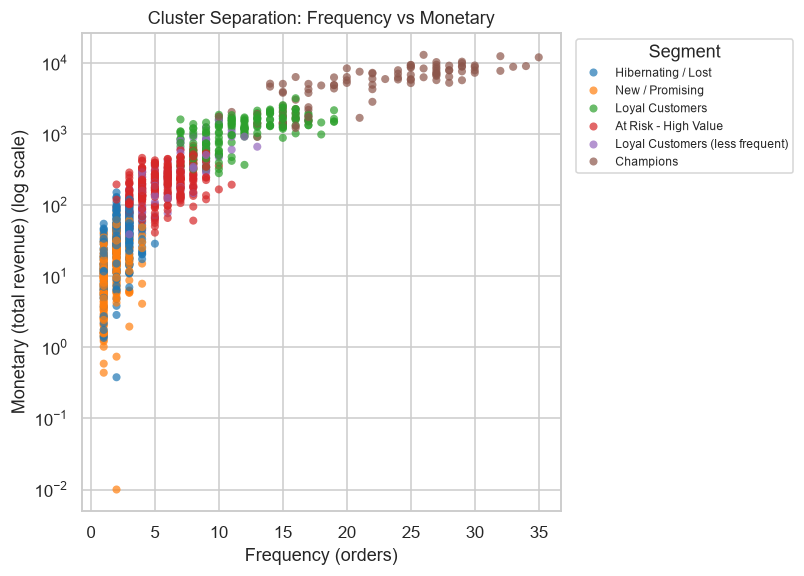

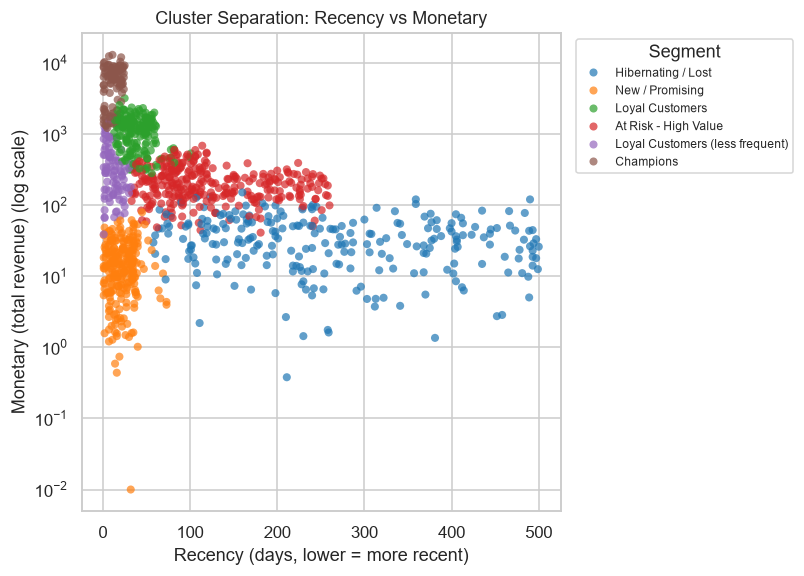

In [19]:
combos = [
    ("Recency", "Frequency", "Recency (days, lower = more recent)", "Frequency (orders)"),
    ("Frequency", "Monetary", "Frequency (orders)", "Monetary (total revenue)"),
    ("Recency", "Monetary", "Recency (days, lower = more recent)", "Monetary (total revenue)"),
]

for x, y, xlab, ylab in combos:
    plt.figure(figsize=(7.5, 5.4))
    sns.scatterplot(data=rfm_clustered, x=x, y=y, hue="Segment",
                    palette="tab10", s=28, alpha=0.7, edgecolor="none")
    if y == "Monetary":
        plt.yscale("log")
        ylab += " (log scale)"
    plt.title(f"Cluster Separation: {x} vs {y}")
    plt.xlabel(xlab); plt.ylabel(ylab)
    plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

The clusters separate cleanly and, importantly, *interpretably*:

* **Recency × Frequency** shows Champions in the top-left (recent and frequent)
  and New/Promising along the bottom (recent but only 1–2 orders).
* **Frequency × Monetary** shows the value funnel — Champions sit far above
  everyone else, which is why they carry 62% of revenue.
* **Recency × Monetary** is the win-back map: the At Risk cluster sits high on
  the y-axis (real historic spend) but far to the right (a long time ago).

---
## 8. Cluster sizes

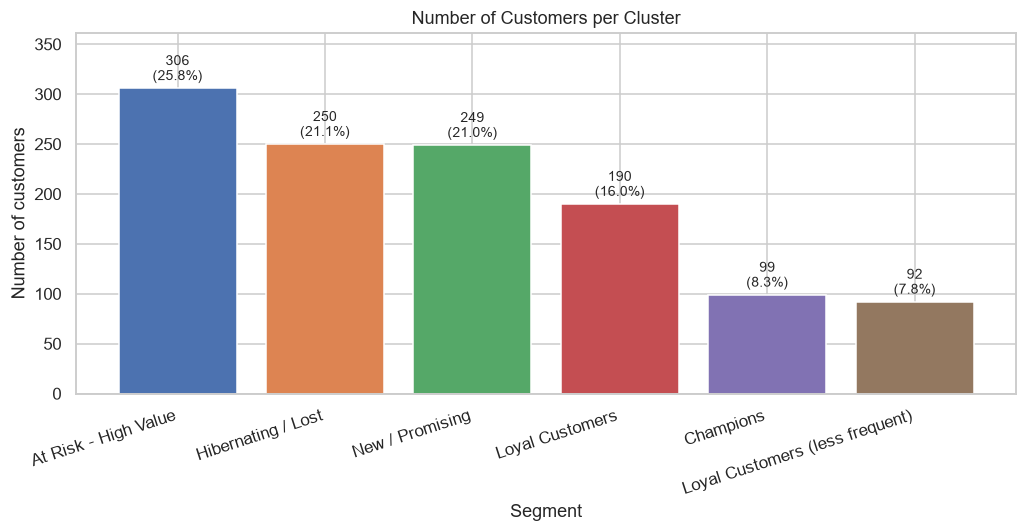

Segment
At Risk - High Value               306
Hibernating / Lost                 250
New / Promising                    249
Loyal Customers                    190
Champions                           99
Loyal Customers (less frequent)     92


In [20]:
counts = rfm_clustered["Segment"].value_counts()

plt.figure(figsize=(9.5, 5))
bars = plt.bar(counts.index, counts.values,
               color=sns.color_palette("deep", len(counts)))
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
             f"{val:,}\n({val / counts.sum():.1%})",
             ha="center", va="bottom", fontsize=9)
plt.title("Number of Customers per Cluster")
plt.ylabel("Number of customers")
plt.xlabel("Segment")
plt.ylim(0, counts.max() * 1.18)
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.show()

print(counts.to_string())

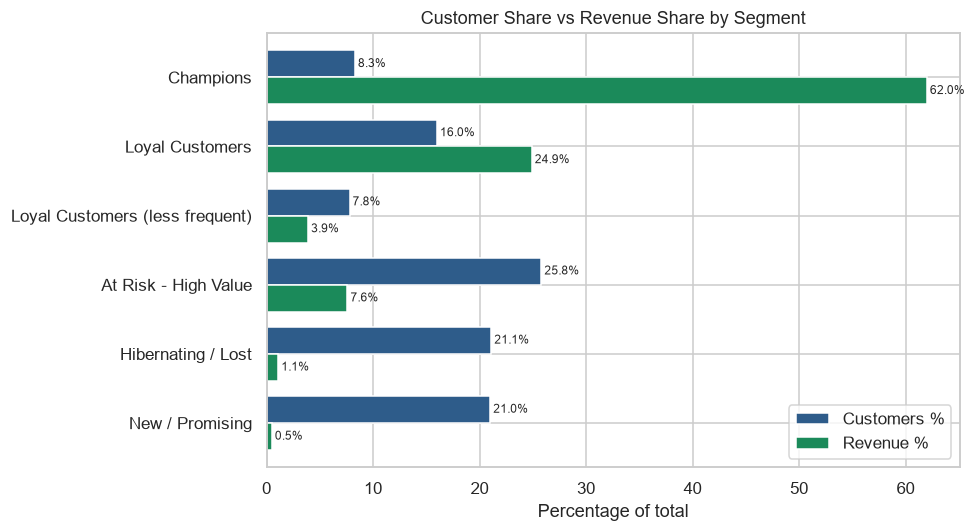

In [21]:
# The point of the exercise: customer share vs revenue share
compare = profile.set_index("Segment")[["CustomerShare_%", "RevenueShare_%"]]

ax = compare.plot(kind="barh", figsize=(9, 5), color=["#2E5C8A", "#1B8A5A"], width=0.78)
ax.set_title("Customer Share vs Revenue Share by Segment")
ax.set_xlabel("Percentage of total")
ax.set_ylabel("")
ax.legend(["Customers %", "Revenue %"])
ax.invert_yaxis()
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

This chart is the strongest argument for the whole analysis. The bars for
**Champions** are wildly lopsided — a small slice of customers producing the
majority of revenue — while **New / Promising** and **Hibernating** show the
mirror image: they consume customer-management effort but contribute almost
nothing. The marketing response for each group should be radically different.

---
## 9. Insights — recommended marketing action per segment

In [22]:
segments_sorted = profile.sort_values("RevenueShare_%", ascending=False)

for _, row in segments_sorted.iterrows():
    name = row["Segment"]
    action = rfm_lib.MARKETING_ACTIONS.get(
        name.split(" (")[0],
        "Review segment definition - no action template matched.",
    )
    print("=" * 96)
    print(f"{name.upper()}")
    print(
        f"  {row['Customers']:,.0f} customers ({row['CustomerShare_%']:.1f}% of base)  |  "
        f"{row['RevenueShare_%']:.1f}% of revenue  |  "
        f"R={row['Recency']:.0f}d  F={row['Frequency']:.1f}  M={row['Monetary']:,.0f}"
    )
    print("-" * 96)
    print("  " + action)
print("=" * 96)

CHAMPIONS
  99 customers (8.3% of base)  |  62.0% of revenue  |  R=12d  F=21.8  M=5,596
------------------------------------------------------------------------------------------------
  Reward and retain. VIP/loyalty tier with early access to new drops, free express shipping and a personal account manager for the top spenders. Ask for reviews and referrals -- they are your best advocates. Avoid discounting; it only trains them to wait for sales.
LOYAL CUSTOMERS
  190 customers (16.0% of base)  |  24.9% of revenue  |  R=39d  F=11.5  M=1,170
------------------------------------------------------------------------------------------------
  Increase share of wallet. Cross-sell premium and complementary categories, offer bundle upgrades, a replenishment/subscription option and free-shipping thresholds set just above their current average order value. They already trust you -- grow basket size, not discount depth.
AT RISK - HIGH VALUE
  306 customers (25.8% of base)  |  7.6% of revenue  |  

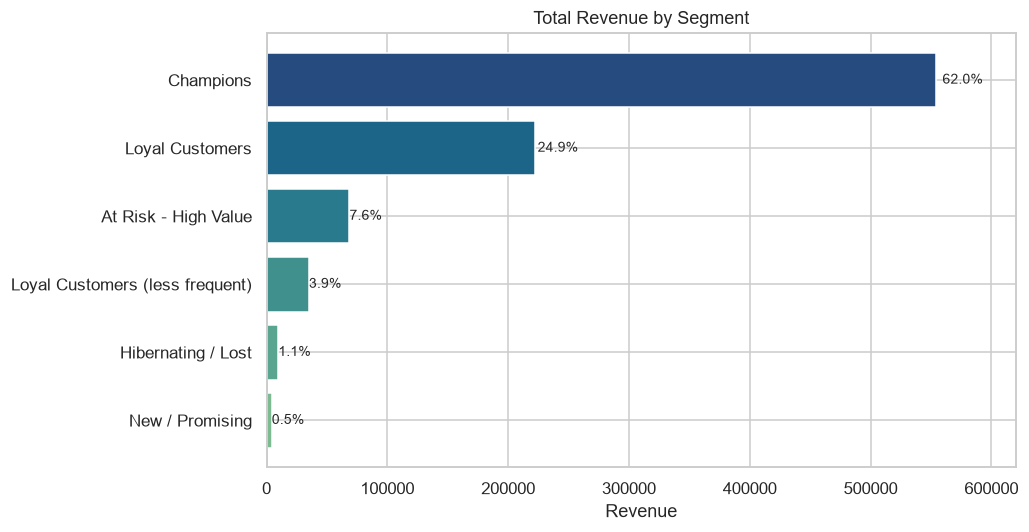

In [23]:
# Where the money actually is: revenue contribution, ranked
fig, ax = plt.subplots(figsize=(9.5, 5))
rev = profile.sort_values("Revenue", ascending=True)
ax.barh(rev["Segment"], rev["Revenue"], color=sns.color_palette("crest", len(rev)))
ax.set_title("Total Revenue by Segment")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
for i, (v, p) in enumerate(zip(rev["Revenue"], rev["RevenueShare_%"])):
    ax.text(v * 1.01, i, f"{p:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, rev["Revenue"].max() * 1.12)
plt.tight_layout()
plt.show()

### 9b. Summary of recommended actions

| Segment | Diagnosis | Recommended marketing action | Success metric |
|---|---|
| **Champions** *(8% of customers, 62% of revenue)* | Recent, frequent, very high spend. Already loyal. | **Reward, do not discount.** VIP tier: early access to new ranges, free express shipping, dedicated support, referral programme. Discounting them only trains them to wait for sales and gives away margin you already have. | Retention rate; referral volume; AOV held flat or up |
| **Loyal Customers** *(16% / 25% of revenue)* | Recent and valuable, but well below Champions on frequency. | **Grow frequency, not basket.** Replenishment/subscription offers, points-based loyalty to add orders, personalised cross-sell into adjacent categories. | Orders per customer per year |
| **Loyal Customers (less frequent)** *(8% / 4% of revenue)* | Recent but low frequency and modest spend. | **Trade up.** Bundle offers, free-shipping thresholds set just above their current average order value, recommendations based on past purchases. | Average order value |
| **At Risk – High Value** *(26% / 8% of revenue)* | High historic spend but ~4 months since last order. **The single biggest recoverable pool.** | **Urgent win-back.** Automated win-back flow with a meaningful personal offer, a short feedback survey, and human outreach for the highest-value individuals. Act now — this group decays into Hibernating. | Reactivation rate within 90 days |
| **New / Promising** *(21% / 0.5% of revenue)* | Recent but almost no repeat behaviour (1–2 orders). The habit is not yet formed. | **Onboard and convert.** Strong welcome series in the first 30 days, time-limited second-purchase incentive, educational content. Cheapest segment to influence because they are still engaged. | % reaching 2nd and 3rd order |
| **Hibernating / Lost** *(21% / 1% of revenue)* | Lapsed 8+ months and low value. | **Minimise spend / sunset.** Exclude from paid campaigns — cost per reactivation exceeds expected value. At most one low-cost seasonal email, then suppress to protect deliverability and margin. | Cost per reactivation vs CLV |

### Prioritisation

1. **At Risk – High Value** first. Largest recoverable revenue, and the clock is ticking on their decay.
2. **Champions** second. Protecting 62% of revenue is worth more than any acquisition campaign.
3. **New / Promising** third. Cheapest to influence while still engaged; getting them to order #2 is the highest-leverage conversion in the funnel.
4. **Hibernating** last, and deliberately cheap. Spend here mostly destroys margin.

A useful rule of thumb from the profile: revenue is so concentrated that a
1-point improvement in **Champions** retention is worth more than a 10-point
improvement in **Hibernating** reactivation.

---
## 10. Limitations

Being explicit about what this analysis does *not* establish:

* **K-Means imposes spherical, equal-sized clusters.** The segments are a
  useful approximation, not a discovered ground truth. DBSCAN or a Gaussian
  mixture would allow different shapes and could be compared.
* **Silhouette ≈ 0.39** indicates real but moderate structure — expected for
  behavioural data, where segments blend into one another rather than forming
  clean islands.
* **The snapshot date drives Recency.** Any production run must use a fixed
  "today" consistently, or segments will shift for a calendar reason rather
  than a behavioural one.
* **RFM is behavioural, not attitudinal.** It cannot distinguish a lapsed
  customer from one who switched to a competitor or simply had no need. It is
  a targeting tool, not an explanation.
* **No margin or returns-adjusted view.** Monetary is gross revenue; a segment
  of heavy returners can look valuable while destroying profit.
* **This dataset is synthetic** (schema-compatible with UCI Online Retail).
  The pipeline can be pointed at the real CSV by changing `DATA_PATH`; the
  absolute numbers would change, the method would not.